## WorldView Stereopair Selection: SpaceNet Atlanta Example

This notebook documents the stereo-pair selection analysis used to choose candidate pairs from the [SpaceNet Off-Nadir Building Detection Challenge](https://spacenet.ai/off-nadir-building-detection/) dataset over Atlanta, Georgia.

The goal is to scan the 27 usable WV2 CATIDs hosted under `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/metadata/`, compute pair geometry with `asp_plot.stereopair_metadata_parser`, and select pairs with stable imaging geometry for the urban-dominated Atlanta airport processing ROI.

### Background: stable imaging geometry

Jeong, J. & Kim, T. (2016), *Comparison of positioning accuracy of a rigorous sensor model and two rational function models for weak stereo geometry*, ISPRS Journal of Photogrammetry and Remote Sensing 82(8): 625–633 — <https://www.sciencedirect.com/science/article/abs/pii/S0099111216301021>:

> Stable imaging geometry, in addition to a precise sensor model, is also necessary to achieve detailed mapping. The stability of the imaging geometry can be expressed by the values of three angles: the convergence, bisector elevation (BIE), and asymmetry angles. The convergence angle reflects the base-to-height ratio; the BIE angle describes the obliqueness of the epipolar plane; the asymmetry angle specifies the level of symmetry between the left and right observation rays. In the ideal imaging geometry, the epipolar plane would be orthogonal (90° BIE angle) and symmetric (0° asymmetry angle) to the ground plane, to avoid accuracy degradation.

So the ideal is **BIE → 90°** and **asymmetry → 0°**. In this notebook these two angles are treated as **secondary tiebreakers**: they only move a pair up or down the ranking when they are notably far from ideal (BIE ≲ 70°, asymm ≳ 12°).

### Convergence target for this scene

Purely urban stereo analyses cite **~5–15°** as the ideal convergence range — see Aguilar, M.Á. et al. (2019), *3D modelling of urban structures from very high resolution satellite imagery: a comparative analysis of convergence angle effect*, European Journal of Remote Sensing, 52(sup1): 1–13 — <https://www.tandfonline.com/doi/full/10.1080/22797254.2018.1551069#abstract>. Small convergence reduces occlusion and matching failures on tall, steep-sided building facades.

The Atlanta processing ROI is centered on **Hartsfield-Jackson Atlanta International Airport** — a mix of flat runway and terminal infrastructure with some residential and wooded areas nearby. As with UCSD, we target **~15–25°** convergence to balance occlusion concerns on built-up structures against height precision over flatter terrain:

- **Urban-only scenes**: ~5–15° is ideal (minimizes building occlusion).
- **Natural / low-slope terrain**: higher convergence (≳ 25°) is beneficial — the larger base-to-height ratio improves vertical precision where occlusion is not the limiting factor.
- **Mixed urban + natural scenes (Atlanta, UCSD)**: **~15–25°** is a practical middle ground.

### Scoring priority

| Priority | Criterion | Direction |
|---|---|---|
| Primary | Convergence angle | Target 15–25° |
| Primary | ROI overlap (containment of the Atlanta airport ROI) | Full containment required |
| Primary | Temporal separation \|Δt\| (days) | Smaller |
| Primary | Solar geometry similarity (\|Δsun_el\|, \|Δsun_az\|) | Smaller |
| Primary | Off-nadir angle per scene | Smaller (finer GSD, less oblique) |
| Primary | Sensor consistency | WV2 + WV2 (all Atlanta scenes are WV2) |
| Secondary | BIE angle | Tiebreaker; penalize only if ≲ 70° |
| Secondary | Asymmetry angle | Tiebreaker; penalize only if ≳ 12° |

---

### Atlanta-specific data layout notes

Each CATID's imagery is **tiled** into multiple P1BS images (`P001`, `P002`, `P003`, sometimes up to `P005`). The raw L1B NTFs and tile XMLs live under `metadata/<CATID>/<workorder>_<PNNN>_PAN/`. For scene selection we only need the XML camera models (satellite/sun angles, footprint polygon), which are very small (~1 MB each). This notebook downloads all tile XMLs for every CATID.

For each CATID the acquisition geometry (sat az/el, sun az/el, GSD) is identical across tiles — they all come from the same satellite pass. The **footprint**, however, differs per tile. We therefore:

- use the first tile's XML for the per-scene geometry values,
- union all tile polygons to get the full CATID footprint for overlap analysis.


---

## Setup

This notebook only downloads the tile XMLs (very small). It does **not** download the ~2 GB NTF imagery for any CATID.

In [1]:
import os
import shutil
import subprocess
import tempfile
from itertools import combinations
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import union_all
from shapely.geometry import box

from asp_plot.stereopair_metadata_parser import StereopairMetadataParser
from asp_plot.utils import get_xml_tag

WORK_DIR = Path("/tmp/atlanta_scene_selection")
XML_DIR = WORK_DIR / "xmls"
FLAT_DIR = WORK_DIR / "flat_xmls"
for d in (WORK_DIR, XML_DIR, FLAT_DIR):
    d.mkdir(parents=True, exist_ok=True)

S3_PREFIX = "s3://spacenet-dataset/AOIs/AOI_6_Atlanta/metadata/"

# Atlanta airport ROI — UTM Zone 16N (EPSG:32616), xmin ymin xmax ymax
# (from worldview_spacenet_atlanta_stereo.ipynb: ~5.7 x 5.4 km over Hartsfield-Jackson)
T_PROJWIN = (735685, 3722295, 741350, 3727695)
UTM_EPSG = 32616


## 1. Discover CATIDs and download tile XMLs

We look for `metadata/<CATID>/` entries (plain catid form, not the duplicated `Atlanta_nadirXX_catid_<CATID>/` form — those only hold manifest files). For each CATID we `aws s3 cp` only the `.XML` files under its `*_PAN/` subdirectories.

In [2]:
# List the plain-CATID subdirectories under metadata/
result = subprocess.run(
    ["aws", "s3", "ls", "--no-sign-request", S3_PREFIX],
    capture_output=True, text=True, check=True,
)
catids = []
for line in result.stdout.strip().splitlines():
    parts = line.split()
    if len(parts) >= 2 and parts[0] == "PRE":
        name = parts[1].rstrip("/")
        # Keep only pure catid dirs (16 hex chars starting with "103")
        if name.startswith("103") and len(name) == 16:
            catids.append(name)

print(f"Found {len(catids)} usable CATIDs.")
for c in catids[:5]:
    print(" ", c)
print("  ...")


Found 27 usable CATIDs.
  10300100023BC100
  1030010002649200
  1030010002B7D800
  103001000307D800
  1030010003127500
  ...


In [3]:
# Download all P1BS XML files under each CATID's PAN tile subdirectories.
# Using s3 sync with --include filters keeps this to only the XMLs (small).
for cid in catids:
    dst = XML_DIR / cid
    if dst.exists() and list(dst.rglob("*.XML")):
        continue  # already downloaded
    dst.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["aws", "s3", "--no-sign-request", "sync",
         f"{S3_PREFIX}{cid}/", str(dst),
         "--exclude", "*",
         "--include", "*_PAN/*P1BS*.XML",
         "--only-show-errors"],
        check=True,
    )

# Flatten all CATID-tile XMLs into FLAT_DIR with a name that keeps the CATID:
for cid in catids:
    for xml in (XML_DIR / cid).rglob("*P1BS*.XML"):
        # e.g. 09DEC22163632-P1BS-058332932010_01_P001.XML → <cid>__<original>
        dst = FLAT_DIR / f"{cid}__{xml.name}"
        if not dst.exists():
            shutil.copy(xml, dst)

n_xmls = len(list(FLAT_DIR.glob("*.XML")))
print(f"Tile XMLs on disk: {n_xmls}")


Tile XMLs on disk: 90


## 2. Extract per-CATID metadata

For each CATID we parse the first tile's XML for geometry (sat/sun angles, GSD) — these are identical across the tiles of one CATID since they all come from the same pass. The **footprint** is built by unioning polygons from all tiles of the CATID.

In [4]:
# Dummy parser — we use its instance methods without relying on image_list.
tmp_dir = tempfile.mkdtemp()
any_xmls = sorted(FLAT_DIR.glob("*.XML"))
for x in any_xmls[:2]:
    shutil.copy(x, tmp_dir)
parser = StereopairMetadataParser(tmp_dir)

scene_dicts = []
rows = []

for cid in catids:
    tile_xmls = sorted(FLAT_DIR.glob(f"{cid}__*.XML"))
    if not tile_xmls:
        print(f"skip {cid}: no XMLs")
        continue

    # First tile for geometry values
    rep_xml = str(tile_xmls[0])
    xml_catid = get_xml_tag(rep_xml, "CATID")
    assert xml_catid == cid, f"catid mismatch for {rep_xml}: expected {cid}, got {xml_catid}"

    d = parser.get_id_dict(cid, rep_xml, geteph=True)

    # Replace the single-tile footprint with the union across all tiles
    tile_polys = [parser.xml2poly(str(x)) for x in tile_xmls]
    d["geom"] = union_all(tile_polys)
    d["fp_gdf"] = gpd.GeoDataFrame(
        {"idx": [0], "geometry": d["geom"]}, geometry="geometry", crs="EPSG:4326",
    )

    scene_dicts.append(d)
    rows.append({
        "catid": d["catid"],
        "sensor": d["sensor"],
        "date": d["date"],
        "n_tiles": len(tile_xmls),
        "off_nadir": d["meanoffnadirviewangle"],
        "sat_az": d["meansataz"],
        "sat_el": d["meansatel"],
        "sun_az": d["meansunaz"],
        "sun_el": d["meansunel"],
        "gsd_m": d["meanproductgsd"],
        "cloud": d["cloudcover"],
    })

scene_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
print(f"{len(scene_df)} scenes parsed.")
scene_df


27 scenes parsed.


,catid,sensor,date,n_tiles,off_nadir,sat_az,sat_el,sun_az,sun_el,gsd_m,cloud
0,103001000392F600,WV02,2009-12-22 16:35:10.817775,3,33.5,2.8,52.0,163.6,31.3,0.65,0.02
1,1030010003315300,WV02,2009-12-22 16:35:20.904975,3,30.1,1.1,55.9,163.6,31.3,0.60,0.02
2,103001000307D800,WV02,2009-12-22 16:35:31.393775,3,26.5,358.8,60.3,163.6,31.3,0.57,0.01
3,1030010003127500,WV02,2009-12-22 16:35:41.879575,3,22.4,355.5,64.9,163.7,31.3,0.54,0.01
4,1030010002649200,WV02,2009-12-22 16:35:52.762175,3,18.1,350.3,69.8,163.7,31.3,0.51,0.01
5,1030010002B7D800,WV02,2009-12-22 16:36:00.344175,3,13.7,342.2,74.8,163.8,31.2,0.49,0.00
6,1030010003993E00,WV02,2009-12-22 16:36:10.258375,3,11.2,332.0,77.6,163.8,31.3,0.48,0.01
7,1030010003D22F00,WV02,2009-12-22 16:36:21.288575,3,8.1,304.5,81.0,163.9,31.3,0.48,0.01
8,10300100023BC100,WV02,2009-12-22 16:36:32.488575,3,8.0,263.8,81.0,163.9,31.3,0.48,0.01
9,1030010003CAF100,WV02,2009-12-22 16:36:39.943775,3,10.7,236.5,77.9,164.0,31.3,0.48,0.00


## 3. Enumerate all unique pairs and compute geometry metrics

With {N} scenes we have $\binom{{N}}{{2}}$ candidate pairs. For each pair we compute convergence / BH / BIE / asymmetry via `parser.pair_dict`, plus intersection, temporal delta, solar deltas, and ROI containment.

In [5]:
roi_utm_poly = box(*T_PROJWIN)
roi_latlon_poly = (
    gpd.GeoDataFrame(geometry=[roi_utm_poly], crs=f"EPSG:{UTM_EPSG}")
    .to_crs("EPSG:4326")
    .geometry.iloc[0]
)

pair_rows = []
for d1, d2 in combinations(scene_dicts, 2):
    if d1["date"] > d2["date"]:
        d1, d2 = d2, d1
    pairname = f"{d1['catid']}_{d2['catid']}"
    p = parser.pair_dict(d1, d2, pairname)

    dt_days = p["dt"].total_seconds() / 86400.0
    delta_sun_el = abs(d1["meansunel"] - d2["meansunel"])
    dsun_az = abs(d1["meansunaz"] - d2["meansunaz"])
    delta_sun_az = min(dsun_az, 360 - dsun_az)

    if p["intersection"] is not None:
        roi_contained = p["intersection"].contains(roi_latlon_poly)
        inter_area = p["intersection_area"]
        inter_perc = min(p["intersection_area_perc"])
    else:
        roi_contained = False
        inter_area = None
        inter_perc = None

    pair_rows.append({
        "pairname": pairname,
        "catid1": d1["catid"], "catid2": d2["catid"],
        "date1": d1["date"], "date2": d2["date"],
        "dt_days": round(dt_days, 2),
        "conv_ang": p["conv_ang"],
        "bh_ratio": p["bh"],
        "bie_ang": p["bie"],
        "asymm_ang": p.get("asymmetry_angle"),
        "inter_km2": inter_area,
        "inter_perc_min": inter_perc,
        "roi_contained": roi_contained,
        "off_nadir1": d1["meanoffnadirviewangle"],
        "off_nadir2": d2["meanoffnadirviewangle"],
        "delta_sun_el": round(delta_sun_el, 2),
        "delta_sun_az": round(delta_sun_az, 2),
    })

pair_df = pd.DataFrame(pair_rows)
print(f"Computed {len(pair_df)} pairs.")
print(f"Pairs fully containing the ROI: {pair_df.roi_contained.sum()}")
print(f"Pairs with convergence in 15–25°: {((pair_df.conv_ang >= 15) & (pair_df.conv_ang <= 25)).sum()}")


Computed 351 pairs.
Pairs fully containing the ROI: 351
Pairs with convergence in 15–25°: 54


## 4. Filter and score

### Filters

1. Intersection polygon must fully contain the Atlanta airport ROI (`roi_contained == True`).
2. Convergence must not be missing.

### Scoring

```text
score = 3.0 · conv_penalty            # 0 inside [15, 25°], else distance from that band
      + 0.15 · dt_days
      + 0.30 · |Δsun_el|
      + 0.10 · |Δsun_az|
      + 0.10 · mean(off_nadir1, off_nadir2)
      + 5.0  · (bie_ang < 70)
      + 5.0  · (asymm_ang > 12)
```

In [6]:
def conv_penalty(c):
    if 15 <= c <= 25:
        return 0.0
    return float(min(abs(c - 15), abs(c - 25)))

scored = pair_df[pair_df.roi_contained & pair_df.conv_ang.notna()].copy()
scored["conv_penalty"] = scored["conv_ang"].apply(conv_penalty)
scored["bie_flag"] = (scored["bie_ang"] < 70).astype(int)
scored["asymm_flag"] = (scored["asymm_ang"] > 12).astype(int)

scored["score"] = (
    3.0  * scored["conv_penalty"]
  + 0.15 * scored["dt_days"]
  + 0.30 * scored["delta_sun_el"]
  + 0.10 * scored["delta_sun_az"]
  + 0.10 * scored[["off_nadir1", "off_nadir2"]].mean(axis=1)
  + 5.0  * scored["bie_flag"]
  + 5.0  * scored["asymm_flag"]
)

scored = scored.sort_values("score").reset_index(drop=True)
print(f"Candidates after filtering: {len(scored)}")

display_cols = [
    "pairname", "dt_days", "conv_ang", "bie_ang", "asymm_ang",
    "inter_perc_min", "delta_sun_el", "delta_sun_az",
    "off_nadir1", "off_nadir2", "score",
]
scored[display_cols].head(15)


Candidates after filtering: 351


,pairname,dt_days,conv_ang,bie_ang,asymm_ang,inter_perc_min,delta_sun_el,delta_sun_az,off_nadir1,off_nadir2,score
0,1030010003993E00_1030010003CAF100,0.0,18.07,81.69,0.10,88.87,0.0,0.2,11.2,10.7,1.115
1,1030010002B7D800_10300100023BC100,0.0,15.97,80.37,4.67,89.81,0.1,0.1,13.7,8.0,1.125
2,1030010003D22F00_10300100039AB000,0.0,17.93,79.83,6.11,83.90,0.0,0.1,8.1,14.9,1.160
3,1030010002B7D800_1030010003CAF100,0.0,21.77,81.57,2.34,96.09,0.1,0.2,13.7,10.7,1.270
4,1030010002649200_10300100023BC100,0.0,21.53,78.62,6.85,88.35,0.0,0.2,18.1,8.0,1.325
5,1030010003993E00_10300100039AB000,0.0,23.97,81.22,3.07,84.66,0.0,0.2,11.2,14.9,1.325
6,1030010002649200_1030010003D22F00,0.0,15.29,76.34,9.98,87.94,0.0,0.2,18.1,8.1,1.330
7,1030010003D22F00_1030010003C92000,0.0,23.58,77.98,8.93,83.79,0.0,0.2,8.1,19.3,1.390
8,10300100023BC100_1030010003C92000,0.0,17.35,75.58,12.05,83.76,0.0,0.2,8.0,19.3,6.385
9,1030010003127500_1030010003D22F00,0.0,20.58,74.18,12.71,85.86,0.0,0.2,22.4,8.1,6.545


## 5. Visualize the ranked candidates

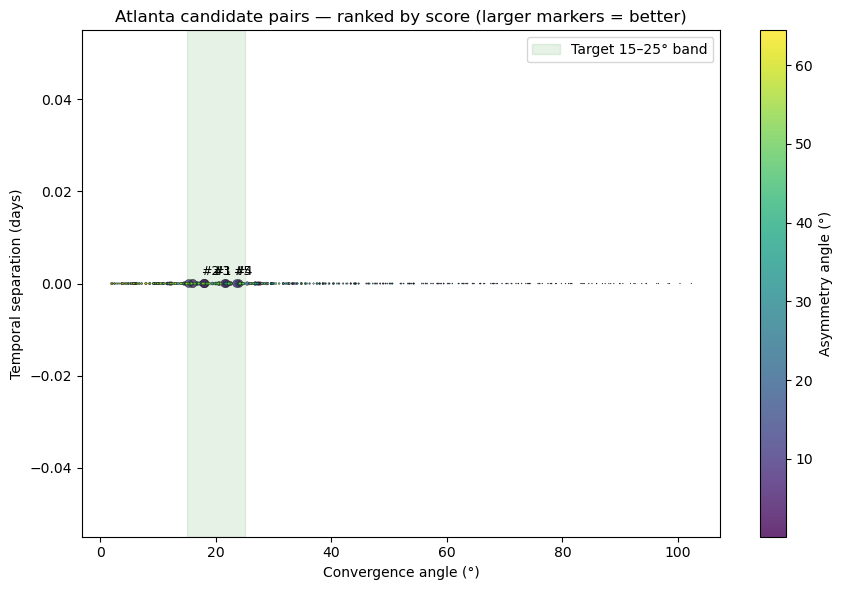

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    scored["conv_ang"], scored["dt_days"],
    c=scored["asymm_ang"], cmap="viridis",
    s=60 * np.clip(1 / (scored["score"] + 0.5), 0, 5),
    alpha=0.8, edgecolor="k", linewidth=0.3,
)
cb = plt.colorbar(sc, ax=ax, label="Asymmetry angle (°)")
ax.axvspan(15, 25, color="green", alpha=0.10, label="Target 15–25° band")
for i in range(min(5, len(scored))):
    row = scored.iloc[i]
    ax.annotate(f"#{i+1}", (row["conv_ang"], row["dt_days"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Convergence angle (°)")
ax.set_ylabel("Temporal separation (days)")
ax.set_title("Atlanta candidate pairs — ranked by score (larger markers = better)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


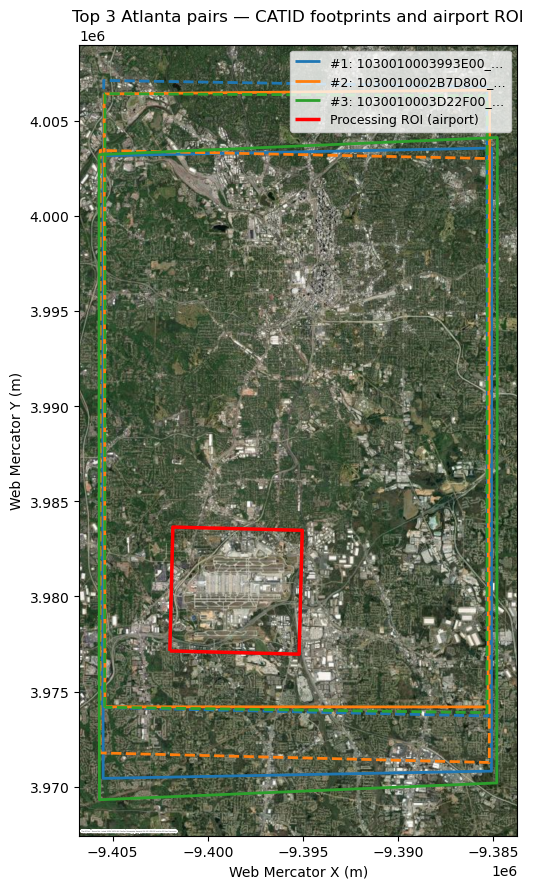

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))

top3_idx = scored.index[:3]
colors = ["tab:blue", "tab:orange", "tab:green"]

for i, (idx, color) in enumerate(zip(top3_idx, colors)):
    row = scored.loc[idx]
    g1 = next(d["geom"] for d in scene_dicts if d["catid"] == row["catid1"])
    g2 = next(d["geom"] for d in scene_dicts if d["catid"] == row["catid2"])
    for g, style in [(g1, "--"), (g2, "-")]:
        gdf = gpd.GeoDataFrame(geometry=[g], crs="EPSG:4326").to_crs(3857)
        gdf.boundary.plot(
            ax=ax, color=color, linestyle=style, linewidth=2,
            label=f"#{i+1}: {row['pairname'][:17]}…" if style == "-" else None,
        )

roi_gdf = gpd.GeoDataFrame(geometry=[roi_utm_poly], crs=f"EPSG:{UTM_EPSG}").to_crs(3857)
roi_gdf.boundary.plot(ax=ax, color="red", linewidth=2.5, label="Processing ROI (airport)")

ctx.add_basemap(ax, crs=3857, source=ctx.providers.Esri.WorldImagery, attribution_size=0)
ax.set_title("Top 3 Atlanta pairs — CATID footprints and airport ROI")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlabel("Web Mercator X (m)")
ax.set_ylabel("Web Mercator Y (m)")
plt.tight_layout()
plt.show()


## 6. Selected pairs

The top-ranked pairs will be carried forward into companion processing notebooks (to be created). Pair metadata (catids, convergence, etc.) is printed below.

This notebook is also idempotent: re-running after a clean `/tmp/atlanta_scene_selection/` wipe will redownload the XMLs from S3.

In [9]:
top3 = scored.head(3)[[
    "pairname", "catid1", "catid2", "date1", "date2",
    "dt_days", "conv_ang", "bie_ang", "asymm_ang",
    "inter_perc_min", "delta_sun_el", "delta_sun_az",
    "off_nadir1", "off_nadir2", "score",
]]
top3


,pairname,catid1,catid2,date1,date2,dt_days,conv_ang,bie_ang,asymm_ang,inter_perc_min,delta_sun_el,delta_sun_az,off_nadir1,off_nadir2,score
0,1030010003993E00_1030010003CAF100,1030010003993E00,1030010003CAF100,2009-12-22 16:36:10.258375,2009-12-22 16:36:39.943775,0.0,18.07,81.69,0.10,88.87,0.0,0.2,11.2,10.7,1.115
1,1030010002B7D800_10300100023BC100,1030010002B7D800,10300100023BC100,2009-12-22 16:36:00.344175,2009-12-22 16:36:32.488575,0.0,15.97,80.37,4.67,89.81,0.1,0.1,13.7,8.0,1.125
2,1030010003D22F00_10300100039AB000,1030010003D22F00,10300100039AB000,2009-12-22 16:36:21.288575,2009-12-22 16:36:50.942575,0.0,17.93,79.83,6.11,83.90,0.0,0.1,8.1,14.9,1.160


## 7. Clean up

In [10]:
shutil.rmtree(WORK_DIR, ignore_errors=True)
print(f"Removed {WORK_DIR}: {not WORK_DIR.exists()}")


Removed /tmp/atlanta_scene_selection: True
